# Spam Email Detection using Machine Learning

## Objective

The objective of this project is to classify SMS messages as Spam or Ham using Machine Learning and explain the prediction using a Large Language Model (Gemini).

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("spam.csv", encoding="latin-1")

df.rename(columns={
    "v1": "label",
    "v2": "message"
}, inplace=True)

df.isnull().sum()

,0
label,0
message,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


### Missing Value Analysis

The `label` and `message` columns contain no missing values, which means every SMS message has a corresponding class label. The additional `Unnamed` columns contain a large number of missing values and are not useful for spam detection. These columns will be removed during data cleaning to simplify the dataset.

In [20]:
df.duplicated().sum()

### Checking Duplicate Records

Duplicate records can affect the quality of a machine learning model by giving repeated importance to the same examples. Using `duplicated().sum()`, we found that the dataset contains 403 duplicate rows. These duplicates will be removed during data cleaning to improve the quality of the dataset.

In [ ]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])
df.columns

In [23]:
df = df.drop_duplicates()
df["label"].value_counts()

,count
label,
ham,4516
spam,653


### Duplicate Record Removal

The dataset initially contained 403 duplicate records. Duplicate rows can introduce bias because the machine learning model repeatedly learns the same examples. These duplicates were removed using the `drop_duplicates()` function, reducing the dataset to 5169 unique SMS messages.

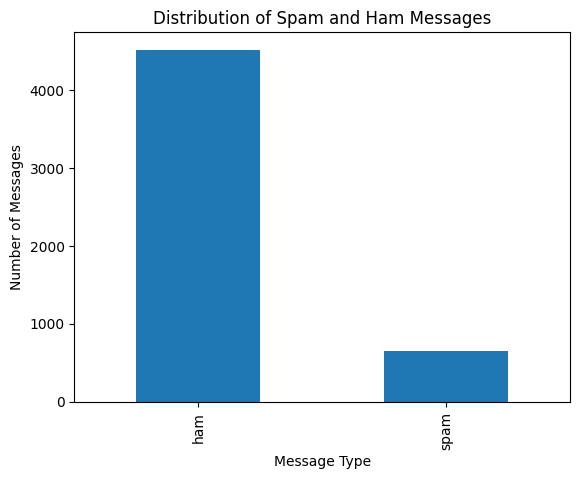

In [25]:
df["label"].value_counts().plot(kind="bar")
df["label"].value_counts().plot(kind="bar")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

### Bar Chart of Message Distribution

A bar chart was created to visualize the number of Ham and Spam messages in the dataset. The chart clearly shows that Ham messages are much more common than Spam messages. This indicates that the dataset is imbalanced, which is an important consideration when building and evaluating a machine learning model.

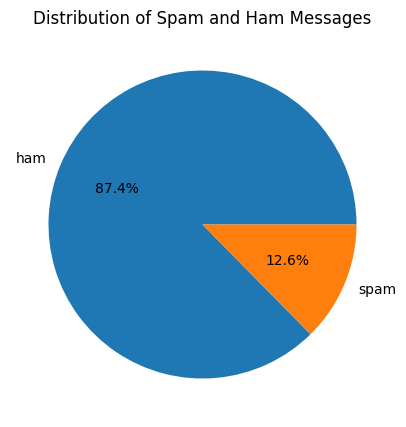

In [26]:
df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(5,5)
)

plt.title("Distribution of Spam and Ham Messages")
plt.ylabel("")   # Removes the extra 'label' text
plt.show()

### Pie Chart of Message Distribution

A pie chart was created to show the proportion of Ham and Spam messages in the dataset. It provides a quick visual representation of the class distribution. The chart shows that Ham messages make up the majority of the dataset, while Spam messages form a much smaller portion.

In [27]:
!pip install wordcloud

In [28]:
from wordcloud import WordCloud

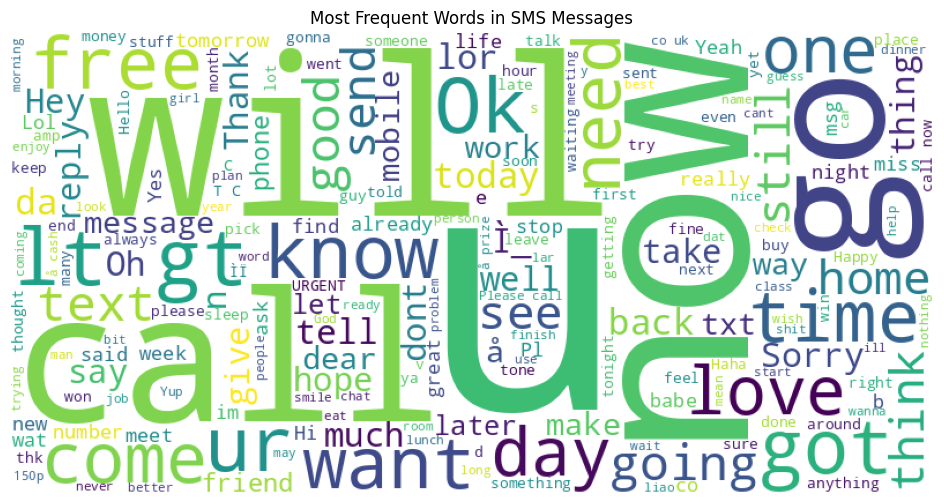

In [29]:
text = " ".join(df["message"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in SMS Messages")
plt.show()

### Word Cloud Visualization

A Word Cloud was generated to display the most frequently occurring words in the SMS dataset. Larger words represent higher frequency, while smaller words appear less often. This visualization helps identify common terms present in the messages and provides insights into the text data before preprocessing. Common words such as "u", "call", and "free" appear frequently, indicating that text preprocessing will be necessary before training the machine learning model.